# Ontwerp en Analyse van een Nok-Mechanisme

**Vak:** Beweging en Trillingen | **Academiejaar:** 2025–2026

---

## Probleemstelling

We ontwerpen een **roterende nok met verticaal translerende rolvolger**. De kern van het ontwerpprobleem is het vinden van een nokcontour dat de gewenste volgerbeweging realiseert, terwijl tegelijk aan drie mechanische eisen wordt voldaan:

1. **Drukhoek** $\alpha < 30°$: beperkt de wrijvingskracht in de geleiding
2. **Geen ondersnijding**: de kromtestraal van de nok $\rho > R_r$ voor de volledige rotatie
3. **Geen zweefgedrag**: de veer houdt de volger altijd in contact met de nok

---

## Systeemparameters

| Parameter | Symbool | Waarde | Eenheid |
|-----------|---------|--------|---------|
| Cyclustijd | $T_{cyclus}$ | 0.5 | s |
| Excentriciteit | $e$ | 0 | mm |
| Equivalente massa | $m$ | 29 | kg |
| Relatieve demping | $\zeta$ | 0.094 | – |
| Veerstijfheid | $k$ | 25 000 | N/m |

## Sleutelwaarden — Snel opzoeken

| Grootheid | Symbool | Waarde |
|-----------|---------|--------|
| Cyclustijd / toerental | $T$ / $n$ | **0,500 s / 120 rpm** — $\omega = 4\pi \approx 12{,}57$ rad/s |
| Steekcirkelstraal | $R_0$ | **50 mm** (min. vereist: 46 mm voor terugkeer) |
| Volgerrolstraal | $R_r$ | **15 mm** |
| Nokbasiscirkelstraal | $R_0 - R_r$ | **35 mm** |
| Excentriciteit | $e$ | 0 mm |
| Max heffing | $s_{max}$ | **50 mm** bij $\theta = 210°$ |
| Max snelheid volger | $v_{max}$ | **0,482 m/s** |
| Max versnelling volger | $a_{max}$ | **±9,89 m/s²** ≈ g |
| Max drukhoek | $\alpha_{max}$ | **+21,86°** / −23,83° → < 30° ✓ |
| Min kromtestraal pitch | $\rho_{min}$ | **40,6 mm** > $R_r = 15$ mm → geen ondersnijding ✓ |

### Bewegingssegmenten

| Segment | Nokhoek ($\beta$) | Heffing | Wet | Opmerking |
|---------|------------------|---------|-----|-----------|
| Heffing 1 | 10°→65° (55°) | 0→10 mm | Poly5 | — |
| Stilstand 1 | 65°→95° (30°) | 10 mm | Dwell | — |
| Heffing 2 | 95°→210° (115°) | 10→50 mm | Poly5 | — |
| **Terugkeer** | **210°→350° (140°)** | **50→0 mm** | **Poly5** | **Maatgevend: grootste $ds/d\theta$** |
| Stilstand 2 | 350°→10° (20°) | 0 mm | Dwell | — |

### Vergelijking bewegingswetten

| Wet | $C_v$ | $C_a$ | RMS | $C_j$ | C²-continu | Opmerking |
|-----|-------|-------|-----|-------|------------|-----------|
| Harmonisch | 1,57 | 4,93 | 3,49 | 15,5 | **Nee** | Laagste $C_a$, maar schokken aan randen |
| Cycloïde | 2,00 | 6,28 | 4,44 | 39,5 | Ja | Hoge $C_a$, lagere ruk dan Poly5 |
| 3e-gr. polynoom | 1,50 | 6,00 | 3,47 | 12,0 | **Nee** | Laagste RMS, maar schokken |
| **5e-gr. polynoom** ✓ | **1,87** | **5,77** | 4,14 | 60,0 | **Ja** | **Gekozen: C² + laagste $C_a$ C²-continu** |

In [11]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib widget

### 1. Invoer van Systeemparameters

De absolute dempingsconstante $c$ wordt afgeleid uit de dimensieloze relatieve demping $\zeta$:
$$c = \zeta \cdot 2\sqrt{k \cdot m}$$

In [12]:
# ============================================================
# Parameters (aanpassen voor wat-als-vragen)
# ============================================================

# Tijds- en snelheidsgegevens
T_cyclus = 0.5                     # Cyclustijd in s
omega = 2.0 * np.pi / T_cyclus     # Toerental in rad/s

# Nokgeometrie
e = 0.0                            # Excentriciteit volger in m
# R_0 en R_r worden bepaald via de Kloomok-Muffley analyse in §4a en §4b

### 2. Bewegingswetten (genormaliseerd)

Elke bewegingswet werkt met een genormaliseerde parameter $\tau \in [0, 1]$ en geeft dimensieloze functies $(y, y', y'', y''')$. De werkelijke kinematica volgt via de kettingregel:

$$s = h \cdot y(\tau), \quad \dot{s} = \frac{h}{\beta}\cdot y'(\tau) \cdot \omega, \quad \ddot{s} = \frac{h}{\beta^2}\cdot y''(\tau) \cdot \omega^2$$

waarbij $h$ de heffing [m] en $\beta$ de nokhoekinterval [rad] van het segment is.

De gekozen bewegingswet is het 5e-graads polynoom: $y(\tau) = 10\tau^3 - 15\tau^4 + 6\tau^5$. De versnellingscurve is continu (klasse $C^2$): er treden geen schokken op in $\ddot{s}$. De ruk heeft eindige sprongen aan de segmentranden.

In [13]:
def dwell_law(tau):
    zeros = np.zeros_like(tau)
    return zeros, zeros, zeros, zeros

def cycloid_law(tau):
    y = tau - np.sin(2 * np.pi * tau) / (2 * np.pi)
    dy = 1.0 - np.cos(2 * np.pi * tau)
    ddy = 2 * np.pi * np.sin(2 * np.pi * tau)
    dddy = 4 * np.pi**2 * np.cos(2 * np.pi * tau)
    return y, dy, ddy, dddy

def poly5_law(tau):
    y = 10 * tau**3 - 15 * tau**4 + 6 * tau**5
    dy = 30 * tau**2 - 60 * tau**3 + 30 * tau**4
    ddy = 60 * tau - 180 * tau**2 + 120 * tau**3
    dddy = 60 - 360 * tau + 360 * tau**2
    return y, dy, ddy, dddy

### 3. Samenstellen van het Heffingsprofiel

De volledige 360°-cyclus wordt opgebouwd uit 5 segmenten. Elk segment definieert een lokale $\tau \in [0,1]$. Aan de grenzen moeten positie en snelheid continu zijn. De dwell-segmenten hebben $\dot{s} = 0$, wat aansluit op de aangrenzende heffsegmenten die ook beginnen en eindigen met $y'(0) = y'(1) = 0$.

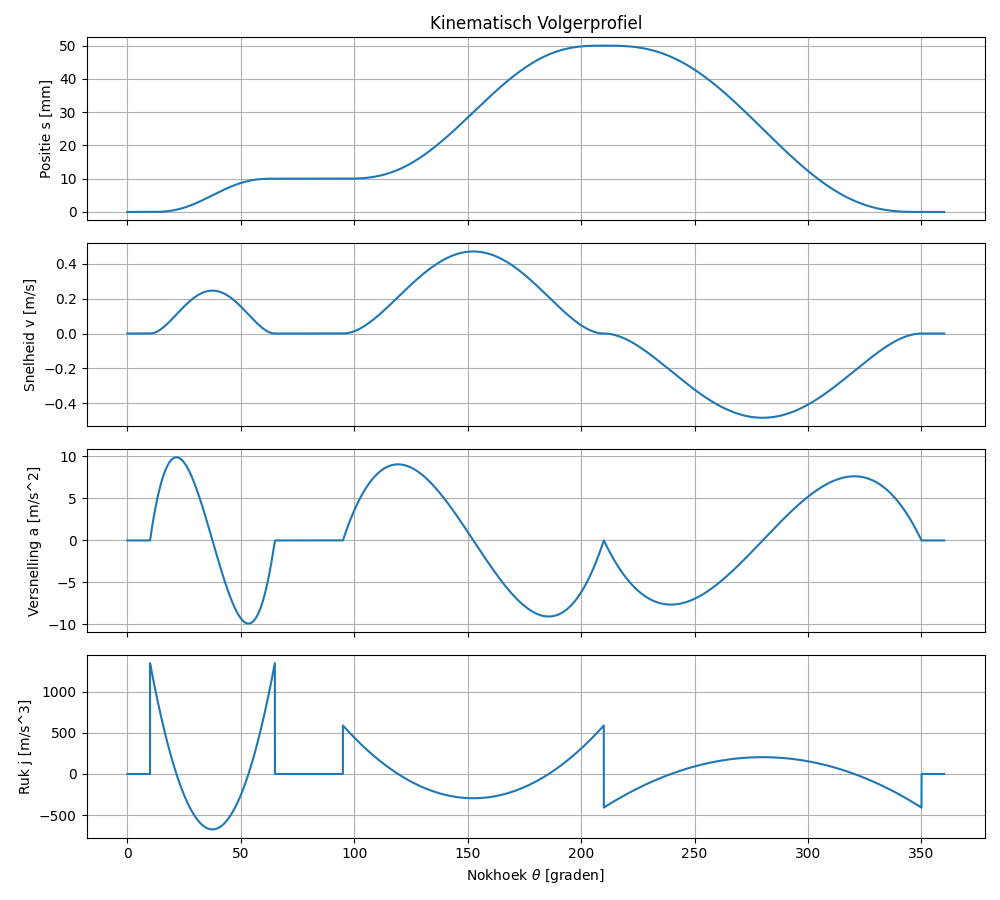

In [14]:
theta_deg = np.linspace(0, 360, 36001)  
theta_rad = np.deg2rad(theta_deg)
time_array = theta_rad / omega

def calc_kinematics_for_profile(theta_array, segments):
    s = np.zeros_like(theta_array)
    v = np.zeros_like(theta_array)
    a = np.zeros_like(theta_array)
    j = np.zeros_like(theta_array)
    
    for (start_hoek, eind_hoek, start_lift, eind_lift, type_wet) in segments:
        beta = eind_hoek - start_hoek
        if beta <= 0:
            beta += 360.0 
            
        beta_rad = np.deg2rad(beta)
        h = eind_lift - start_lift
        
        shifted_deg = (theta_array - start_hoek) % 360.0
        mask = (shifted_deg >= 0) & (shifted_deg <= beta)
        tau = shifted_deg[mask] / beta
        
        if type_wet == 'cycloid':
            y, dy, ddy, dddy = cycloid_law(tau)
        elif type_wet == 'poly5':
            y, dy, ddy, dddy = poly5_law(tau)
        else:
            y, dy, ddy, dddy = dwell_law(tau)
            
        s[mask] = start_lift + h * y
        if type_wet != 'dwell':
            v[mask] = (h / beta_rad) * dy * omega
            a[mask] = (h / (beta_rad**2)) * ddy * (omega**2)
            j[mask] = (h / (beta_rad**3)) * dddy * (omega**3)
            
    return s, v, a, j

profiel_segmenten = [
    (10,   65,  0.0,   0.010, 'poly5'), 
    (65,   95,  0.010, 0.010, 'dwell'), 
    (95,  210,  0.010, 0.050, 'poly5'),
    (210, 350,  0.050, 0.0,   'poly5'), 
    (350,  10,  0.0,   0.0,   'dwell')  
]

s_profiel, v_profiel, a_profiel, j_profiel = calc_kinematics_for_profile(theta_deg, profiel_segmenten)

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
axes[0].plot(theta_deg, s_profiel * 1000)
axes[0].set_ylabel('Positie s [mm]')
axes[0].set_title('Kinematisch Volgerprofiel')
axes[0].grid(True)
axes[1].plot(theta_deg, v_profiel)
axes[1].set_ylabel('Snelheid v [m/s]')
axes[1].grid(True)
axes[2].plot(theta_deg, a_profiel)
axes[2].set_ylabel('Versnelling a [m/s^2]')
axes[2].grid(True)
axes[3].plot(theta_deg, j_profiel)
axes[3].set_ylabel('Ruk j [m/s^3]')
axes[3].set_xlabel(r'Nokhoek $\theta$ [graden]')
axes[3].grid(True)
plt.tight_layout()
plt.show()

### 4. Nokontwerp: $R_0$, $R_r$, Drukhoek en Ondersnijding

De steekcirkelstraal $R_0$ en volgerrolstraal $R_r$ zijn het resultaat van een iteratieve optimalisatie (Kloomok & Muffley, 1957). Daarna worden het nokprofiel, de drukhoek en de kromtestraal berekend en geplot.

#### 4a. Steekcirkelstraal $R_0$ — Drukhoekconditie

Voor elke kandidaatwaarde van $R_0$ wordt de maximale drukhoek per bewegingssegment berekend:

$$\alpha_{max}(R_0) = \max_{\tau \in [0,1]} \arctan\!\left(\frac{ds/d\theta}{R_0 + s(\tau)}\right)$$

Kies de kleinste $R_0$ waarvoor alle segmenten voldoen aan $|\alpha| < 30°$.

=== Kloomok-Muffley: R₀ Drukhoekanalyse per Segment ===


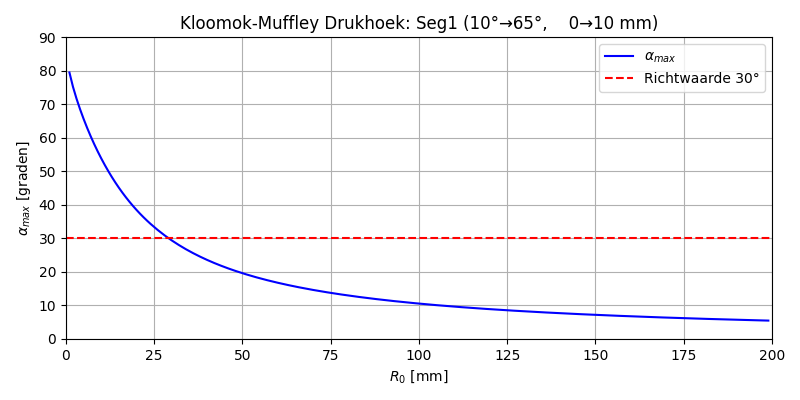

  Seg1 (10°→65°,    0→10 mm): minimale R₀ = 30.0 mm voor α_max < 30°


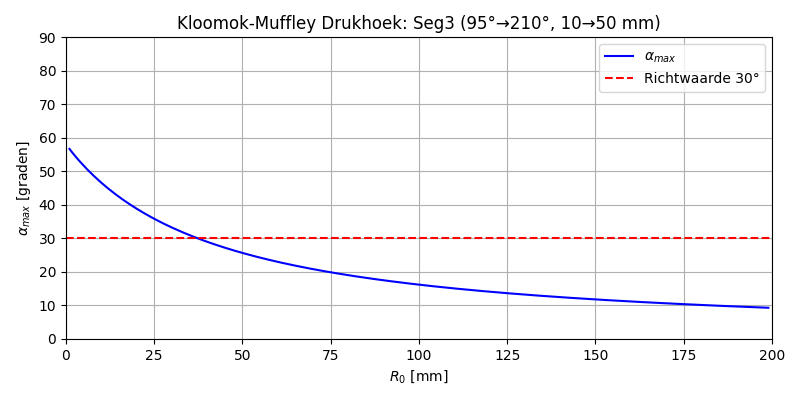

  Seg3 (95°→210°, 10→50 mm): minimale R₀ = 38.0 mm voor α_max < 30°


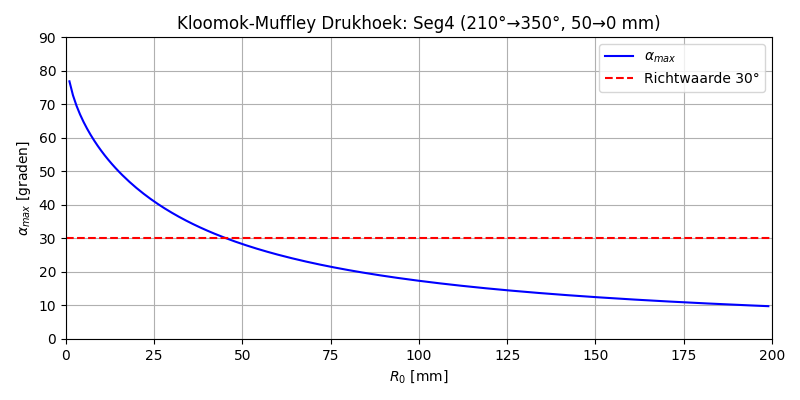

  Seg4 (210°→350°, 50→0 mm): minimale R₀ = 46.0 mm voor α_max < 30°


In [15]:
R0_zoekvec       = np.arange(0.001, 0.200, 0.001)  # zoekruimte: 1 mm → 200 mm
alpha_max_per_R0 = np.zeros_like(R0_zoekvec)

def KM_drukhoek_analyse(beta_deg, startlift_m, endlift_m, type_wet, titel=''):
    """Kloomok-Muffley: max. drukhoek per R0-kandidaat voor één bewegingssegment."""
    global R0_zoekvec, alpha_max_per_R0
    beta_rad = np.deg2rad(beta_deg)
    h = endlift_m - startlift_m
    x = np.linspace(0, 1, 200)
    for i, R0 in enumerate(R0_zoekvec):
        if   type_wet == 'poly5':   y_n, dy_n, _, _ = poly5_law(x)
        elif type_wet == 'cycloid': y_n, dy_n, _, _ = cycloid_law(x)
        else:
            alpha_max_per_R0[i] = 0.0; continue
        lift    = startlift_m + h * y_n      # s(τ) in meters
        vel_ang = (h / beta_rad) * dy_n      # ds/dθ in m/rad
        alpha_max_per_R0[i] = np.max(np.abs(np.arctan2(vel_ang, R0 + lift))) * 180/np.pi
    plt.figure(figsize=(8, 4))
    plt.plot(R0_zoekvec * 1000, alpha_max_per_R0, 'b-', label=r'$\alpha_{max}$')
    plt.axhline(30, color='r', linestyle='--', label='Richtwaarde 30°')
    plt.xlabel('$R_0$ [mm]'); plt.ylabel(r'$\alpha_{max}$ [graden]')
    plt.title(f'Kloomok-Muffley Drukhoek: {titel}')
    plt.xlim([0, 200]); plt.ylim([0, 90]); plt.grid(True); plt.legend()
    plt.tight_layout(); plt.show()
    geldig = R0_zoekvec[alpha_max_per_R0 < 30]
    if len(geldig):
        print(f"  {titel}: minimale R₀ = {geldig[0]*1000:.1f} mm voor α_max < 30°")
    else:
        print(f"  {titel}: α < 30° niet haalbaar in de zoekruimte!")

print("=== Kloomok-Muffley: R₀ Drukhoekanalyse per Segment ===")
KM_drukhoek_analyse( 55, 0.000, 0.010, 'poly5', 'Seg1 (10°→65°,    0→10 mm)')
KM_drukhoek_analyse(115, 0.010, 0.050, 'poly5', 'Seg3 (95°→210°, 10→50 mm)')
KM_drukhoek_analyse(140, 0.050, 0.000, 'poly5', 'Seg4 (210°→350°, 50→0 mm)')

Maatgevend segment: Segment 4 (terugkeer, $h = 50\,\text{mm}$, $\beta = 140°$) heeft de grootste $ds/d\theta$ en bepaalt de drukhoek.

Keuze: $R_0 = 50\,\text{mm}$.

In [16]:
R_0 = 0.050  # Steekcirkelstraal in m — bepaald via Kloomok-Muffley drukhoekanalyse
print(f"Gekozen R_0 = {R_0*1000:.0f} mm  (alle segmenten: α_max < 30°)")

Gekozen R_0 = 50 mm  (alle segmenten: α_max < 30°)


#### 4b. Volgerrolstraal $R_r$ — Ondersnijdingscriterium

De volgerrolstraal is begrensd door het ondersnijdingscriterium: $\rho_{min} > R_r$ voor alle $\theta$:

$$\rho_{pitch}(\theta) = \frac{\left[(R_0 + s)^2 + \left(\frac{ds}{d\theta}\right)^2\right]^{3/2}}{(R_0+s)^2 + 2\left(\frac{ds}{d\theta}\right)^2 - (R_0+s)\cdot\frac{d^2s}{d\theta^2}}$$

Lees de waarde af bij de werkelijke span van elk segment. $R_r$ moet kleiner zijn dan de kleinste $\rho_{min}$ over alle segmenten.

=== Kloomok-Muffley: R_r Ondersnijdingsanalyse per Segment ===


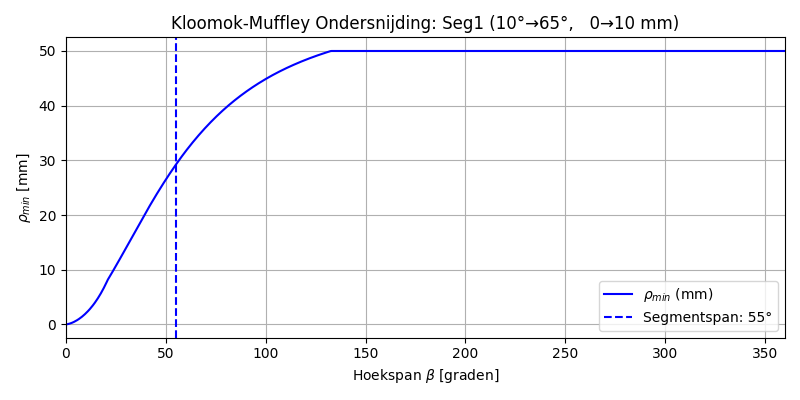

  Seg1 (10°→65°,   0→10 mm): bij β=55° → ρ_min = 29.2 mm  →  R_r moet < 29.2 mm


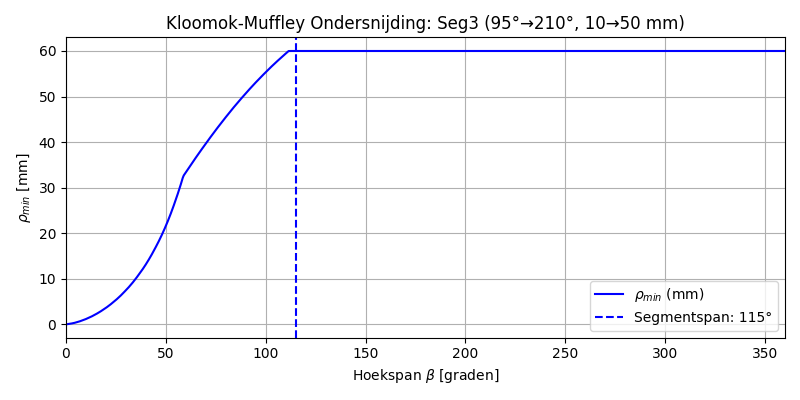

  Seg3 (95°→210°, 10→50 mm): bij β=115° → ρ_min = 60.0 mm  →  R_r moet < 60.0 mm


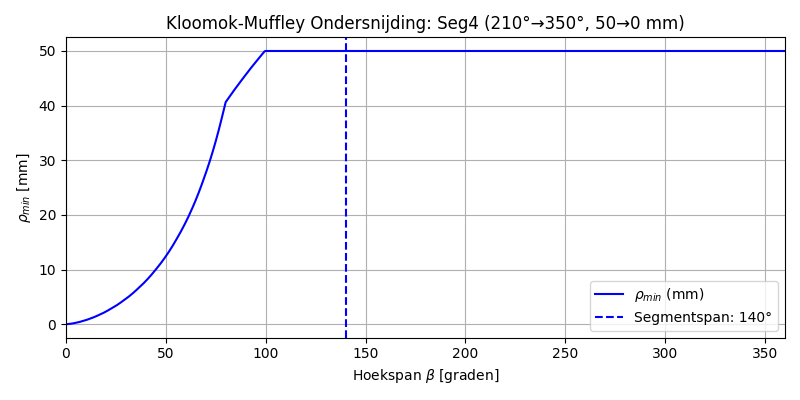

  Seg4 (210°→350°, 50→0 mm): bij β=140° → ρ_min = 50.0 mm  →  R_r moet < 50.0 mm


In [17]:
beta_km_vec = np.arange(1, 360, 0.5)
rho_min_km  = np.zeros_like(beta_km_vec)

def KM_ondersnijding_analyse(R0, span_deg, startlift_m, endlift_m, type_wet, titel=''):
    """Kloomok-Muffley: minimale kromtestraal steekkromme voor alle beta in zoekruimte."""
    global beta_km_vec, rho_min_km
    h = endlift_m - startlift_m
    for i, beta_d in enumerate(beta_km_vec):
        beta_r = np.deg2rad(beta_d)
        x = np.linspace(0, 1, 100)
        if   type_wet == 'poly5':   y_n, dy_n, ddy_n, _ = poly5_law(x)
        elif type_wet == 'cycloid': y_n, dy_n, ddy_n, _ = cycloid_law(x)
        else:
            rho_min_km[i] = np.inf; continue
        lift    = startlift_m + h * y_n
        vel_ang = (h / beta_r)    * dy_n
        acc_ang = (h / beta_r**2) * ddy_n
        numer = ((R0 + lift)**2 + vel_ang**2)**1.5
        denom = (R0 + lift)**2 + 2*vel_ang**2 - (R0 + lift)*acc_ang
        with np.errstate(divide='ignore', invalid='ignore'):
            rho = np.where(np.abs(denom) > 1e-15, numer/denom, np.inf)
        rho_min_km[i] = np.min(np.abs(rho))
    idx = np.argmin(np.abs(beta_km_vec - span_deg))
    rho_bij_span = rho_min_km[idx]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(beta_km_vec, np.array(rho_min_km)*1000, 'b-', label=r'$\rho_{min}$ (mm)')
    ax.axvline(x=span_deg, color='b', linestyle='--', label=f'Segmentspan: {span_deg}°')
    ax.set_xlabel(r'Hoekspan $\beta$ [graden]')
    ax.set_ylabel(r'$\rho_{min}$ [mm]')
    ax.set_title(f'Kloomok-Muffley Ondersnijding: {titel}')
    ax.set_xlim([0, 360]); ax.grid(True); ax.legend()
    plt.tight_layout(); plt.show()
    print(f"  {titel}: bij β={span_deg}° → ρ_min = {rho_bij_span*1000:.1f} mm  →  R_r moet < {rho_bij_span*1000:.1f} mm")

print("=== Kloomok-Muffley: R_r Ondersnijdingsanalyse per Segment ===")
KM_ondersnijding_analyse(R_0,  55, 0.000, 0.010, 'poly5', 'Seg1 (10°→65°,   0→10 mm)')
KM_ondersnijding_analyse(R_0, 115, 0.010, 0.050, 'poly5', 'Seg3 (95°→210°, 10→50 mm)')
KM_ondersnijding_analyse(R_0, 140, 0.050, 0.000, 'poly5', 'Seg4 (210°→350°, 50→0 mm)')

Maatgevend segment: Segment 4 (terugkeer, $h = 50\,\text{mm}$, $\beta = 140°$) geeft de kleinste $\rho_{min}$.

Keuze: $R_r = 15\,\text{mm}$. De nokbasiscirkelstraal is $R_0 - R_r = 35\,\text{mm}$.

In [18]:
R_r = 0.015  # Volgerrolstraal in m — bepaald via ondersnijdingscriterium (zie grafiek hierboven)
print(f"Gekozen R_r  = {R_r*1000:.0f} mm")
print(f"Nokbasiscirkelstraal = R_0 - R_r = {(R_0 - R_r)*1000:.0f} mm")

Gekozen R_r  = 15 mm
Nokbasiscirkelstraal = R_0 - R_r = 35 mm


#### 4c. Nokgeometrie: Drukhoek en Ondersnijding

De drukhoek $\alpha$ met excentriciteit $e$:

$$\tan(\alpha) = \frac{\frac{ds}{d\theta} - e}{\sqrt{(R_0 + R_r)^2 - e^2} + s(\theta)}$$

Richtwaarde: $|\alpha| < 30°$. Een grotere $R_0$ verlaagt de drukhoek; excentriciteit $e$ verlaagt die tijdens de hefsslag en verhoogt die tijdens de terugkeerslag.

Eis voor geen ondersnijding: $\rho_{pitch} > R_r$ voor alle $\theta$.

Evaluatie Ondersnijding:
  Geen ondersnijding (rho_pitch > R_r voor alle theta).


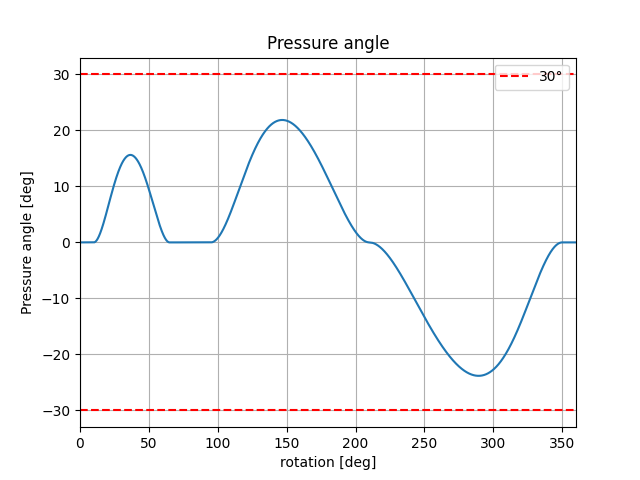

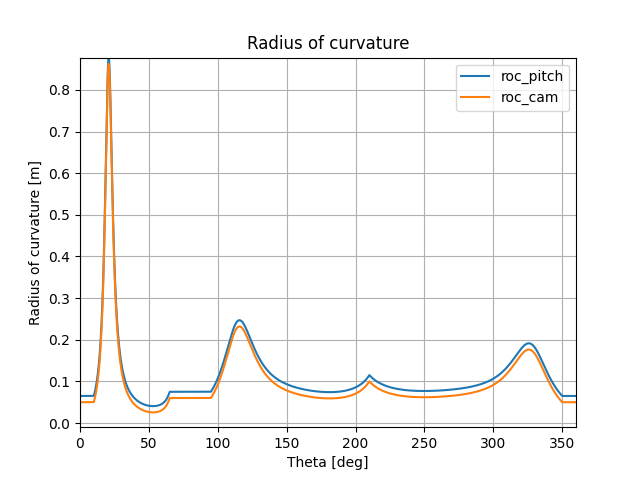

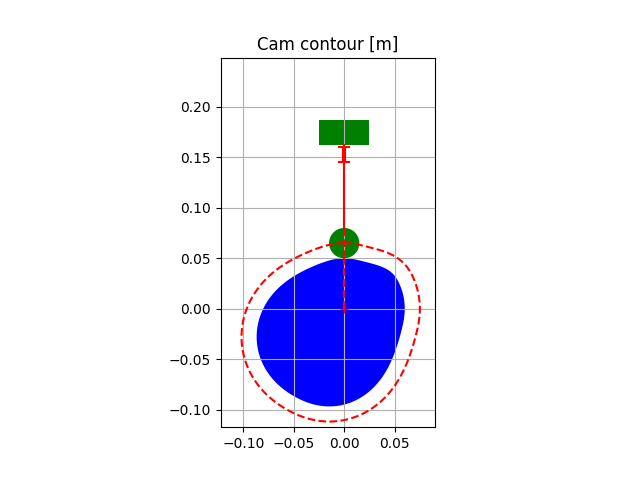

In [19]:
dtheta_deg  = theta_deg[1] - theta_deg[0]          # resolutie in graden
ds_dtheta   = v_profiel / omega                     # ds/dθ  [m/rad]
d2s_dtheta2 = a_profiel / omega**2                  # d²s/dθ² [m/rad²]

# ---------------------------------------------------------------------------
def calculatePressureAngle(vel, exc, base_radius, follower_radius, lift):
    pressure_angle = np.arctan2(vel - exc,
                                np.sqrt((base_radius + follower_radius)**2 - exc**2) + lift)
    return pressure_angle

def plotPressureAngle(theta_deg, pressure_angle):
    plt.figure()
    plt.plot(theta_deg, pressure_angle * 180/np.pi)
    plt.xlabel('rotation [deg]')
    plt.ylabel('Pressure angle [deg]')
    plt.xlim([0, 360])
    plt.axhline( 30, color='r', linestyle='--', label='30°')
    plt.axhline(-30, color='r', linestyle='--')
    plt.grid(True)
    plt.legend()
    plt.title('Pressure angle')

# ---------------------------------------------------------------------------
def calculateRadiusCurvature(base_radius, follower_radius, exc, theta, lift, vel, acc):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2)

    lam   = -theta - np.arctan2(exc, d + lift) + np.pi/2
    dlam  = -1 + exc / ((d + lift)**2 + exc**2) * vel
    ddlam = (exc / ((d + lift)**2 + exc**2) * acc
             - 2*exc*(d + lift)*vel**2 / ((d + lift)**2 + exc**2)**2)

    g   = np.sqrt((d + lift)**2 + exc**2)
    dg  = vel*(d + lift) / np.sqrt((d + lift)**2 + exc**2)
    ddg = ((vel**2 + acc*(d + lift)) / np.sqrt((d + lift)**2 + exc**2)
           - vel**2*(d + lift)**2 / ((d + lift)**2 + exc**2)**(3/2))

    sh = np.sin(lam);  dsh  = np.cos(lam)*dlam
    ddsh = -np.sin(lam)*dlam**2 + np.cos(lam)*ddlam

    cf = np.cos(lam);  dcf  = -np.sin(lam)*dlam
    ddcf = -np.cos(lam)*dlam**2 - np.sin(lam)*ddlam

    dx  = dcf*g  + cf*dg
    ddx = ddcf*g + 2*dcf*dg + cf*ddg
    dy  = dsh*g  + sh*dg
    ddy = ddsh*g + 2*dsh*dg + sh*ddg

    roc_pitch = -(dx**2 + dy**2)**(3/2) / (dx*ddy - dy*ddx)
    roc_cam   = roc_pitch - follower_radius
    return roc_pitch, roc_cam

def plotRadiusCurvature(theta_deg, roc_pitch, roc_cam):
    inds = np.where(np.abs(np.diff(roc_pitch) / dtheta_deg) < 1e1)[0]
    maxi = max(0.010, np.max(roc_pitch[inds + 1]))
    mini = min(-0.010, np.min(roc_pitch[inds + 1]))
    plt.figure()
    plt.plot(theta_deg, roc_pitch, label='roc_pitch')
    plt.plot(theta_deg, roc_cam,   label='roc_cam')
    plt.xlabel('Theta [deg]')
    plt.ylabel('Radius of curvature [m]')
    plt.xlim([0, 360])
    plt.ylim([mini, maxi])
    plt.grid(True)
    plt.legend()
    plt.title('Radius of curvature')

# ---------------------------------------------------------------------------
def plotCamContour(base_radius, follower_radius, exc, theta, lift, pressure_angle, dtheta):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2)

    lam    = -theta - np.arctan2(exc, d + lift) + np.pi/2
    xpitch = np.cos(lam) * np.sqrt((d + lift)**2 + exc**2)
    ypitch = np.sin(lam) * np.sqrt((d + lift)**2 + exc**2)
    xcam   = xpitch + follower_radius * np.cos(-theta + pressure_angle + 3*np.pi/2)
    ycam   = ypitch + follower_radius * np.sin(-theta + pressure_angle + 3*np.pi/2)

    pitch_curve = np.array([xpitch, ypitch])
    cam_curve   = np.array([xcam,   ycam])

    x_rolfol_center = exc
    y_rolfol_center = d + lift[0]
    x_rolfol = follower_radius * np.cos(theta) + x_rolfol_center
    y_rolfol = follower_radius * np.sin(theta) + y_rolfol_center

    min_dist    = 2 * follower_radius
    height_bore = follower_radius
    width_block  = base_radius / 2
    height_block = base_radius / 2

    x_boreleft  = np.array([exc - 0.005, exc - 0.001, exc - 0.001, exc - 0.005])
    x_boreright = np.array([exc + 0.005, exc + 0.001, exc + 0.001, exc + 0.005])
    y_bore = np.array([d + max(lift) + min_dist]     * 2
                    + [d + max(lift) + min_dist + height_bore] * 2)

    length_follower = y_bore[-1] - ypitch[0] - follower_radius + 0.002

    x_follower = np.array([x_rolfol_center, x_rolfol_center])
    y_follower = np.array([y_rolfol_center + follower_radius,
                           y_rolfol_center + follower_radius + length_follower])

    x_block = np.array([-width_block, width_block, width_block, -width_block]) + x_follower[0]
    y_block = np.array([0, 0, height_block, height_block]) + y_follower[1]

    ref_line = np.array([[0, 0], [0, base_radius]])

    x_press = np.array([x_rolfol_center + follower_radius * np.sin(pressure_angle[0]),
                        x_rolfol_center - follower_radius * np.sin(pressure_angle[0])])
    y_press = np.array([y_rolfol_center - follower_radius * np.cos(pressure_angle[0]),
                        y_rolfol_center + follower_radius * np.cos(pressure_angle[0])])

    step = int(1 / dtheta)

    xlimits = [np.min(pitch_curve[0, :]), np.max(pitch_curve[0, :])]
    ylimits = [np.min(pitch_curve[1, :]),
               d + max(lift) + follower_radius + length_follower + height_block]

    plt.figure()
    plt.fill(cam_curve[0, ::step],  cam_curve[1, ::step],  'b')
    plt.fill(x_rolfol[::step],      y_rolfol[::step],      'g')
    plt.plot(pitch_curve[0, ::step], pitch_curve[1, ::step], '--r')
    plt.plot(0, 0, 'r+')
    plt.plot(x_press,    y_press,    'r--')
    plt.plot(ref_line[0, :], ref_line[1, :], 'r--')
    plt.plot(x_boreleft,  y_bore, 'r')
    plt.plot(x_boreright, y_bore, 'r')
    plt.plot(x_follower,  y_follower, 'r')
    plt.fill(x_block, y_block, 'g')
    plt.xlim(np.array(xlimits) * 1.2)
    plt.ylim(np.array(ylimits) * 1.05)
    plt.gca().set_aspect('equal')
    plt.grid(True)
    plt.title('Cam contour [m]')

# ---------------------------------------------------------------------------
# Berekeningen
alpha_rad = calculatePressureAngle(ds_dtheta, e, R_0, R_r, s_profiel)
alpha_deg = np.rad2deg(alpha_rad)

roc_pitch, roc_cam = calculateRadiusCurvature(
    R_0, R_r, e, theta_rad, s_profiel, ds_dtheta, d2s_dtheta2
)

# Nokcontour (globaal assenstelsel)
s_base  = np.sqrt((R_0 + R_r)**2 - e**2)
s_tot   = s_base + s_profiel
X_pitch = s_tot * np.sin(theta_rad) + e * np.cos(theta_rad)
Y_pitch = s_tot * np.cos(theta_rad) - e * np.sin(theta_rad)
X_nok   = X_pitch - R_r * np.sin(theta_rad - alpha_rad)
Y_nok   = Y_pitch - R_r * np.cos(theta_rad - alpha_rad)

# Ondersnijdingscheck
print("Evaluatie Ondersnijding:")
if np.any(roc_pitch <= R_r):
    print("  Fout: rho_pitch < R_r — ondersnijding vastgesteld.")
else:
    print("  Geen ondersnijding (rho_pitch > R_r voor alle theta).")

# Grafieken
plotPressureAngle(theta_deg, alpha_rad)
plt.show()

plotRadiusCurvature(theta_deg, roc_pitch, roc_cam)
plt.show()

plotCamContour(R_0, R_r, e, theta_rad, s_profiel, alpha_rad, dtheta_deg)
plt.show()

### 5. Vergelijkingstabel Bewegingswetten

De tabel toont de dimensieloze piekwaarden van snelheid ($C_v$), versnelling ($C_a$), de RMS-versnelling en de maximale ruk ($C_j$) per bewegingswet. De werkelijke versnelling is $a_{max} = C_a \cdot h \cdot \omega^2 / \beta^2$.

In [20]:
import pandas as pd

def harmonic_law(tau):
    y    = 0.5 * (1 - np.cos(np.pi * tau))
    dy   = 0.5 * np.pi * np.sin(np.pi * tau)
    ddy  = 0.5 * np.pi**2 * np.cos(np.pi * tau)
    dddy = -0.5 * np.pi**3 * np.sin(np.pi * tau)
    return y, dy, ddy, dddy

def poly3_law(tau):
    y    = 3*tau**2 - 2*tau**3
    dy   = 6*tau - 6*tau**2
    ddy  = 6 - 12*tau
    dddy = -12 * np.ones_like(tau)
    return y, dy, ddy, dddy

taus = np.linspace(0, 1, 1000)

laws = {
    'Harmonisch':                  harmonic_law,
    'Cycloide':                    cycloid_law,
    '3e gr. polynoom (min. RMS)':  poly3_law,
    '5e gr. polynoom':             poly5_law,
}

rows = []
for name, func in laws.items():
    y, dy, ddy, dddy = func(taus)
    rows.append({
        'Bewegingswet':  name,
        'Cv (max vel)':  round(float(np.max(np.abs(dy))),  2),
        'Ca (max acc)':  round(float(np.max(np.abs(ddy))), 2),
        'RMS acc':       round(float(np.sqrt(np.mean(ddy**2))), 2),
        'Cj (max jerk)': round(float(np.max(np.abs(dddy))), 1),
        'C2 continu':    'Nee' if name in ('Harmonisch', '3e gr. polynoom (min. RMS)') else 'Ja',
    })

display(pd.DataFrame(rows))

,Bewegingswet,Cv (max vel),Ca (max acc),RMS acc,Cj (max jerk),C2 continu
0,Harmonisch,1.57,4.93,3.49,15.5,Nee
1,Cycloide,2.00,6.28,4.44,39.5,Ja
2,3e gr. polynoom (min. RMS),1.50,6.00,3.47,12.0,Nee
3,5e gr. polynoom,1.87,5.77,4.14,60.0,Ja


### 6. Mondelinge Vragen — Kinematica & Geometrie

**V: Waarom het 5e-graads polynoom en niet de cycloid?**
De cycloid heeft een lagere piekversnelling ($C_a = 6.28$) dan het 5e-graads polynoom ($C_a = 5.77$), maar een hogere ruk ($C_j = 39.5$ vs. $60$). Het 5e-graads polynoom blijft $C^2$-continu (geen schokken in $\ddot{s}$) en biedt een goede balans. De keuze hangt af van de gevoeligheid voor trilling vs. piekbelasting op de motor.

**V: Hoe kies je $R_0$?**
Via de Kloomok-Muffley drukhoekanalyse: kies de kleinste $R_0$ waarvoor het maatgevende segment (grootste $ds/d\theta$) voldoet aan $|\alpha| < 30°$. Een grotere $R_0$ verlaagt de drukhoek maar neemt meer inbouwruimte en materiaalkosten.

**V: Wanneer treedt ondersnijding op en hoe vermijd je het?**
Als $\rho_{pitch} \leq R_r$: de roller snijdt in het nokmateriaal en het mechanisme loopt vast. Oplossing: kies een kleinere $R_r$, een grotere $R_0$, of een bewegingswet met lagere versnellingspiek.

**V: Wat is de rol van excentriciteit $e$?**
Excentriciteit verlaagt de drukhoek tijdens de hefsslag maar verhoogt die tijdens de terugkeerslag (asymmetrisch effect). Voordelig als één richting mechanisch kritischer is dan de andere. Bij $e = 0$ is het ontwerp symmetrisch.

**V: Wat betekent $C^2$-continuïteit?**
De versnellingscurve $\ddot{s}$ is continu (geen sprongen): er treden geen schokken op die het mechanisme abrupt belasten. De ruk $\dddot{s}$ heeft eindige sprongen aan de segmentranden — dit is acceptabel voor de 5e-graads polynoom.

**V: Wat is de pitch curve?**
Het pad beschreven door het middelpunt van de rolvolger. De nokcontour bevindt zich op afstand $R_r$ binnenwaarts langs de normaal van de pitch curve. Ondersnijding treedt op als de kromtestraal van de pitch curve kleiner wordt dan $R_r$.